Importation des bibliothèques

In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import random_split
from tqdm import tqdm # pour la progression 
import time #pour le temps de calcul
import copy #pour copier base_model
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print(os.getcwd())  # donne le répertoire courant

d:\INRIA\MCDropout


Fixation du seed pour la reproductibilité

In [3]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # si GPU dispo

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Configuration de base

Importation du modèle déjà entraîné par l'utilisateur

In [4]:
batch_size = 128 #on peut changer la taille mais 128 est bien pour éviter underfitting ou overfitting

transform = transforms.Compose([
    transforms.ToTensor(),                   #Convertir une image en tenseur, met les valeurs des pixels entre 0 et 1
    transforms.Normalize((0.5, 0.5, 0.5),    # Moyenne RGB
                         (0.5, 0.5, 0.5))])  # Écart-type RGB; pixels deviennent centrés autour de 0

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')


Définition du CNN de base (3 couches)

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # entrée 3 channels (RGB)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)  # réduit dimension par 2 à chaque fois
        
        # Calculer la taille en sortie avant les couches fully connected
        # CIFAR10 32x32 → après 3 poolings (x2) → 4x4
        self.fc1 = nn.Linear(64 * 4 * 4, 128) # après les convolutions on a un tenseur de taille 64*4*4, fc1 les réduit en 128 neurones
        self.fc2 = nn.Linear(128, 10)  # 10 classes CIFAR10

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)  # aplatit en [batch_size, 64*4*4 = 1024]
        x = F.relu(self.fc1(x)) #ou fonction sigmoïde à la fin?
        x = self.fc2(x)
        return x



Masque pour le dropout

In [6]:
class CNN_MCdropout(nn.Module):
    def __init__(self, model, dico_layers=None):
        super().__init__()
        self.model = model
        self.dico_layers = dico_layers or {}

        # Remplacement des couches ciblées
        for name, layer in list(self.model._modules.items()):
            if isinstance(layer, nn.Conv2d) and name in self.dico_layers:
                p = self.dico_layers[name]
                self.model._modules[name] = nn.Sequential(layer, nn.ReLU(), nn.Dropout2d(p)) #le dropout est après la fonction d'activation

            elif isinstance(layer, nn.Linear) and name in self.dico_layers:
                p = self.dico_layers[name]
                self.model._modules[name] = nn.Sequential(layer, nn.ReLU(), nn.Dropout(p))
                
    # ici je mets le dropout en sortie, 
    def forward(self, x):
        return self.model.forward(x)
    

Fonction d'entraînement et test

In [7]:
val_ratio = 0.1  # 10% pour validation
train_size = int((1 - val_ratio) * len(trainset))
val_size   = len(trainset) - train_size

# on fixe tjrs les mêmes train et val set
train_subset, val_subset = random_split(trainset, [train_size, val_size], generator=torch.Generator().manual_seed(seed))

trainloader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader   = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)


Fonction d'évaluation (avant entraînement)

In [8]:
def evaluate(model, dataloader, device):
    """"
    Évalue le modèle sur les données du dataloader.
    Retourne la loss moyenne et l'accuracy.
    """
    model.eval() # ou model.train() ?
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            total_loss += criterion(outputs, targets).item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return total_loss/len(dataloader), correct/total

Fonction d'entraînement

In [9]:
def train_model(model, trainloader, valloader, device, epochs=20, save_path="best.pt"):
    """
    Entraîne le modèle et sauvegarde le meilleur modèle selon la validation."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    best_val_acc = 0
    
    for epoch in range(epochs):#petit nombre d'epochs pour tester (environ 1 minutes pas epoch)
        model.train()
        running_loss = 0.0
        for inputs, targets in trainloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        # Évaluer sur validation
        val_loss, val_acc = evaluate(model, valloader, device)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {running_loss/len(trainloader):.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")
        
        # Sauvegarde si amélioration
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
    
    print("Finished Training")
    return model

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_path = "best.pt"

# # Demande à l'utilisateur quelles couches doivent subir le dropout : ou alors il amène sa liste
# user_layers = input(
#     "Sur quelles couches voulez-vous appliquer le MC Dropout ? "
#     "(choisissez parmi conv1, conv2, conv3, fc1, séparées par des virgules) : ")
# mc_layers = [layer.strip() for layer in user_layers.split(',') if layer.strip() in ['conv1','conv2','conv3','fc1']]

# Vérifie si les poids existent déjà
base_model = SimpleCNN()
if os.path.exists(save_path):
    print("Chargement du modèle sauvegardé")
    base_model.load_state_dict(torch.load(save_path, map_location=device))  # même architecture que celle qui a sauvegardé
else:
    print("Pas de modèle sauvegardé, on entraîne le modèle")
    base_model = train_model(base_model, trainloader, valloader, device, epochs=20, save_path=save_path)
    base_model.load_state_dict(torch.load(save_path, map_location=device))  # recharge les meilleurs poids

dico_layers = {
    # "model": base_model,
    # "layers": {
        "conv1": 0.1,
        "conv2": 0.1,
        "conv3": 0.1,
        "fc1": 0.2,
    # }
} #nom : input_dico OU j'enlève le model et je mets le model en argument à part dans la classe générique 

# On fait une copie pour MC Dropout
base_model_mc = copy.deepcopy(base_model)

# # Récupérer le dictionnaire des dropouts
# mc_layers_dict = dico_layers["layers"]

# # Copier le modèle pour le MC Dropout
# base_model_dict = copy.deepcopy(dico_layers["model"])

# # Créer le modèle MC Dropout générique correctement
model = CNN_MCdropout(base_model_mc, dico_layers=dico_layers).to(device)
# model = CNN_MCdropout(base_model_dict, dico_layers=mc_layers_dict).to(device) 

# Évaluation finale du modèle sans dropout
test_loss, test_acc = evaluate(model, testloader, device)
print(f"Final Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.4f}")

Chargement du modèle sauvegardé
Final Test Loss: 0.8186 - Test Acc: 0.7267
Final Test Loss: 0.8186 - Test Acc: 0.7267


MC Dropout prédiction

In [11]:
def mc_predict_mean_probs(model, X, T=1000, verbose=True):
    """
    Effectue T passes Monte Carlo Dropout sur le modèle pour le batch X,
    retourne la moyenne des probabilités softmax sur T passes.
    Permet d'estimer l'incertitude du modèle via dropout activé à l'inférence.
    """
    model.train()  # activer dropout pendant l'inférence MC
    probs_list = []
    start_time = time.time() 
    with torch.no_grad():
        for _ in tqdm(range(T), disable=not verbose):
            logits_t = model(X)
            probs_t = F.softmax(logits_t, dim=1)
            probs_list.append(probs_t.unsqueeze(0))
    elapsed = time.time() - start_time
    probs_mc = torch.cat(probs_list, dim=0)       
    model.eval()  # remettre le modèle en mode eval à la fin
    if verbose:
        print(f"Temps total: {elapsed:.2f} s  |  Temps moyen par passe: {elapsed/T:.4f} s")
    return probs_mc.mean(0), elapsed                        

je dois garder le même batch ; mettre des seeds pour que ce soit reproductible (fonction de dropout)

In [12]:
# Test MC Dropout sur un batch
X, Y = next(iter(testloader))
X, Y = X.to(device), Y.to(device)
probs, t1 = mc_predict_mean_probs(model, X, T=1000, verbose=True)
Y_hat = probs.argmax(1)

print("Classes vraies       :", Y.tolist())
print(f"Classes prédites    : {Y_hat.tolist()}")

acc = (Y_hat == Y).float().mean().item()
print(f"MC Dropout Test Acc: {acc:.4f}")


100%|██████████| 1000/1000 [00:19<00:00, 52.52it/s]

Temps total: 19.06 s  |  Temps moyen par passe: 0.0191 s
Classes vraies       : [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3, 6, 2, 1, 2, 3, 7, 2, 6, 8, 8, 0, 2, 9, 3, 3, 8, 8, 1, 1, 7, 2, 5, 2, 7, 8, 9, 0, 3, 8, 6, 4, 6, 6, 0, 0, 7, 4, 5, 6, 3, 1, 1, 3, 6, 8, 7, 4, 0, 6, 2, 1, 3, 0, 4, 2, 7, 8, 3, 1, 2, 8, 0, 8, 3]
Classes prédites    : [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 2, 4, 9, 4, 2, 4, 0, 9, 6, 6, 5, 4, 3, 9, 3, 4, 1, 9, 5, 4, 6, 3, 6, 0, 9, 3, 3, 7, 6, 9, 8, 6, 3, 8, 8, 5, 5, 5, 3, 7, 5, 6, 3, 6, 6, 1, 0, 3, 7, 8, 6, 8, 8, 0, 2, 2, 3, 3, 8, 8, 1, 1, 7, 2, 2, 2, 8, 8, 9, 0, 3, 8, 6, 4, 6, 6, 0, 0, 3, 4, 5, 6, 3, 1, 1, 2, 6, 8, 5, 6, 0, 2, 2, 9, 3, 0, 4, 3, 5, 8, 3, 1, 2, 8, 0, 8, 3]
MC Dropout Test Acc: 0.7969


rajouter en argument de generate_mc_outputs measure = variance (en gros on laisse à l'utilisateur le choix de la mesure d'incertitude)

In [13]:
def generate_mc_outputs(model, X, T=1000, metrics=["mc_estimate"], labels=None, verbose=True):
    """
    Effectue T passes Monte Carlo Dropout sur le modèle pour le batch X,
    calcule les métriques d'incertitude spécifiées.
    Retourne les sorties de chaque passe, la moyenne des probabilités softmax,
    un dictionnaire des valeurs de métriques, et les temps de calcul."""
    model.train()
    outputs = []
    mean_probs = None 

    start_forward = time.time()
    with torch.no_grad():
        for _ in tqdm(range(T), disable=not verbose):
            out = model(X)
            outputs.append(out.unsqueeze(0))
    elapsed_forward = time.time() - start_forward

    outputs = torch.cat(outputs, dim=0)  # [T, batch, num_classes]
    results = {}
    elapsed_metrics = {}

    # Calcul de la classe prédite initialement (premier passage sans dropout)
    with torch.no_grad():
        first_logits = model(X)
        first_probs = torch.softmax(first_logits, dim=1)
        initial_pred = first_probs.argmax(dim=1)  # [batch], classe prédite pour chaque échantillon
        
    all_probs = torch.softmax(outputs, dim=2)  
    mean_probs = all_probs.mean(dim=0) 

    for metric in metrics:
        start_metric = time.time()

        if metric == "mc_estimate":
            results[metric] = mean_probs

        elif metric == "variance_predicted": # var des probas softmax de la classe prédite initialement
            idx = initial_pred.unsqueeze(0).expand(T, -1) # matrice avec T lignes égales à initial_pred
            selected_probs = all_probs.gather(2, idx.unsqueeze(2)).squeeze(2) # pour chaque batch, on prend la colonne de la classe prédite initialement
            var_pred_class = selected_probs.var(dim=0) 
            results["variance_predicted_mean"] = var_pred_class.mean().item()
            results["variance_predicted"] = var_pred_class

        elif metric == "variance_max": # variance des probas max (toutes classes confondues) 
            max_probs, _ = all_probs.max(dim=2)  # shape [T, batch]
            var_max = max_probs.var(dim=0)  # shape [batch]
            results["variance_max_mean"] = var_max.mean().item()
            results["variance_max"] = var_max

        elif metric == "predictive_entropy_predicted": # PE pour la classe prédite initialement      
            idx = initial_pred.unsqueeze(1)          
            selected_mean_probs = mean_probs.gather(1, idx).squeeze(1) # on sélectionne la proba moyenne de la classe prédite
            # entropie binaire pour la classe prédite (p*log(p) + (1-p)*log(1-p))
            entropies_pred = -(selected_mean_probs * (selected_mean_probs + 1e-12).log() +
                               (1 - selected_mean_probs) * ((1 - selected_mean_probs + 1e-12).log()))
            results["predictive_entropy_predicted_mean"] = entropies_pred.mean().item()
            results["predictive_entropy_predicted"] = entropies_pred

        elif metric == "predictive_entropy_max": # PE de la probabilité max (toutes classes confondues)
            max_probs, _ = mean_probs.max(dim=1)  # shape [batch]
            # entropie binaire associée à p_max
            entropies = -(max_probs * (max_probs + 1e-12).log() +
                          (1 - max_probs) * ((1 - max_probs + 1e-12).log()))
            results["predictive_entropy_max_mean"] = entropies.mean().item()
            results["predictive_entropy_max"] = entropies

        elif metric == "relative_norm":
            if labels is None:
                raise ValueError("labels doivent être fournis pour relative_norm")
            labels_onehot = F.one_hot(labels, num_classes=mean_probs.size(1)).float()
            diff_norm = torch.norm(mean_probs - labels_onehot, dim=1)
            denom = torch.max(torch.norm(mean_probs, dim=1), torch.norm(labels_onehot, dim=1))
            relative_norm = diff_norm / (denom + 1e-12)
            results[metric + "_mean"] = relative_norm.mean().item()
            results[metric] = relative_norm

        else:
            raise ValueError(f"Métrique {metric} non reconnue")

        elapsed_metrics[metric] = time.time() - start_metric

    model.eval()

    if verbose:
        print(f"Temps forward pass: {elapsed_forward:.2f}s  |  Temps moyen par passe: {elapsed_forward/T:.4f}s")
        for m, t in elapsed_metrics.items():
            print(f"Temps calcul métrique '{m}': {t:.6f}s")

    return outputs, mean_probs, results, elapsed_forward, elapsed_metrics


le mc estimate n'est pas une mesure d'incertitude, sert pour construire une autre variable

Métriques

In [16]:
user_metrics = input(
    "Quelles métriques voulez-vous calculer ?\n"
    "Options disponibles : mc_estimate, variance_predicted, variance_max, predictive_entropy_predicted, predictive_entropy_max, relative_norm\n"
    "Vous pouvez en choisir plusieurs, séparées par des virgules : "
)
user_metrics = [m.strip() for m in user_metrics.split(",")]

outputs, mean_probs, metric_values, elapsed_forward, elapsed_metrics = generate_mc_outputs(
    model, X, T=1000, metrics=user_metrics, labels=Y, verbose=False
)

print(f"\nListe des métriques choisies par l'utilisateur : {user_metrics}")
print(f"Temps total des forward passes : {elapsed_forward:.2f} s\n")

for metric in user_metrics:
    print(f"--- Métrique choisie : {metric} ---")
    print(f"Temps de calcul : {elapsed_metrics[metric]:.6f} s")

    metric_result = metric_values[metric]

    if metric == "mc_estimate":
        print(f"Distribution de probabilités moyennes (par échantillon) :\n{metric_result}\n")
    
    elif metric == "variance_max":
        print(f"Variance moyenne (logits) : {metric_values['variance_max_mean']:.6f}")
        print(f"Variance par échantillon :\n{metric_result}\n")

    elif metric == "variance_predicted":
        print(f"Variance softmax moyenne : {metric_values['variance_predicted_mean']:.6f}")
        print(f"Variance softmax par échantillon :\n{metric_result}\n")

    elif metric == "predictive_entropy_max":
        print(f"Entropie prédictive moyenne : {metric_values['predictive_entropy_max_mean']:.6f}")
        print(f"Entropie prédictive par échantillon :\n{metric_result}\n")

    elif metric == "predictive_entropy_predicted":
        print(f"Entropie attendue moyenne : {metric_values['predictive_entropy_predicted_mean']:.6f}")
        print(f"Entropie attendue par échantillon :\n{metric_result}\n")

    elif metric == "relative_norm":
        print(f"Norme relative moyenne : {metric_values['relative_norm_mean']:.6f}")
        print(f"Norme relative par échantillon :\n{metric_result}\n")

    else:
        print(f"Résultat brut :\n")



Liste des métriques choisies par l'utilisateur : ['mc_estimate', 'variance_predicted', 'variance_max', 'predictive_entropy_predicted', 'predictive_entropy_max', 'relative_norm']
Temps total des forward passes : 12.64 s

--- Métrique choisie : mc_estimate ---
Temps de calcul : 0.000000 s
Distribution de probabilités moyennes (par échantillon) :
tensor([[0.0286, 0.0161, 0.0249,  ..., 0.0055, 0.1250, 0.0149],
        [0.0199, 0.3461, 0.0027,  ..., 0.0008, 0.6058, 0.0088],
        [0.1769, 0.0883, 0.0248,  ..., 0.0201, 0.4993, 0.0496],
        ...,
        [0.4329, 0.1105, 0.2204,  ..., 0.0010, 0.0902, 0.0665],
        [0.2372, 0.0049, 0.0834,  ..., 0.0040, 0.4132, 0.0118],
        [0.0152, 0.0017, 0.0283,  ..., 0.0286, 0.0070, 0.0147]])

--- Métrique choisie : variance_predicted ---
Temps de calcul : 0.005942 s
Variance softmax moyenne : 0.085249
Variance softmax par échantillon :
tensor([0.1037, 0.1378, 0.0063, 0.1096, 0.1339, 0.0036, 0.1146, 0.0495, 0.0396,
        0.1046, 0.1192, 0.11

Seuil de variance_predicted

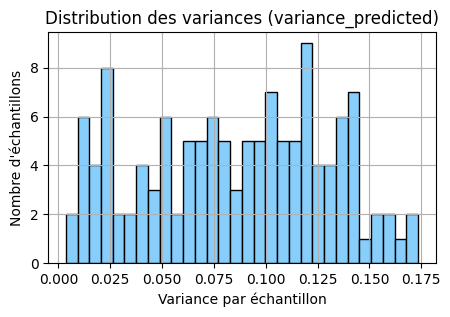

In [17]:
variances = metric_values['variance_predicted']
if torch.is_tensor(variances):
    variances = variances.cpu().numpy()

plt.figure(figsize=(5,3))
plt.hist(variances, bins=30, color='lightskyblue', edgecolor='black')
plt.xlabel("Variance par échantillon")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution des variances (variance_predicted)")
plt.grid(True)
plt.show()

In [18]:
def accuracy_threshold(Y_hat, Y, values, metric_name="mesure", num_thresholds=1000, color='blue'):
    """
    Trace la courbe accuracy en fonction du seuil sur une métrique donnée.
    Y_hat : prédictions (tensor ou array)
    Y : labels réels (tensor ou array)
    values : vecteur par échantillon de la métrique utilisée comme seuil (variance, predictive entropy, etc.)
    metric_name : nom de la métrique (sera utilisé dans le titre)
    num_thresholds : nombre de seuils à tester
    color : couleur de la courbe
    """
    # Conversion en numpy si besoin
    if torch.is_tensor(Y_hat): Y_hat = Y_hat.cpu().numpy()
    if torch.is_tensor(Y): Y = Y.cpu().numpy()
    if torch.is_tensor(values): values = values.cpu().numpy()

    thresholds = np.linspace(values.min(), values.max(), num_thresholds)
    accuracies = []

    for thresh in thresholds:
        mask = values < thresh
        if mask.sum() == 0:
            accuracies.append(np.nan)
        else:
            acc = (Y_hat[mask] == Y[mask]).mean()
            accuracies.append(acc)

    accuracies = np.array(accuracies)

    # Valeur minimale d'accuracy
    min_accuracy = np.nanmin(accuracies)

    plt.figure(figsize=(7,4))
    plt.plot(thresholds, accuracies, color=color, linewidth=2)
    
    plt.axhline(y=min_accuracy, color='red', linestyle='--', label=f"Accuracy min = {min_accuracy:.4f}")
    
    plt.xlabel(f"Seuil sur {metric_name}")
    plt.ylabel("Accuracy (Y_hat = Y)")
    plt.title(f"Accuracy en fonction du seuil de {metric_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


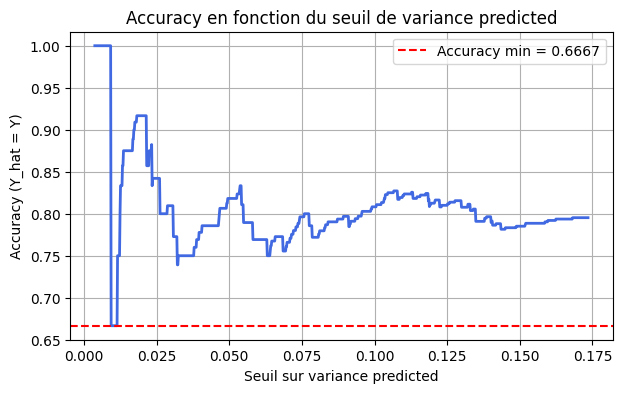

In [19]:
accuracy_threshold(Y_hat, Y, metric_values['variance_predicted'], metric_name="variance predicted", color="royalblue")

Seuil de variance_max

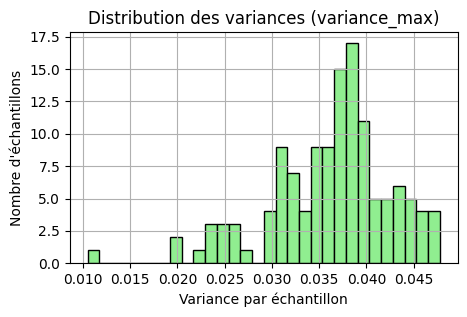

In [20]:
variances = metric_values['variance_max']
if torch.is_tensor(variances):
    variances = variances.cpu().numpy()

plt.figure(figsize=(5,3))
plt.hist(variances, bins=30, color='lightgreen', edgecolor='black')
plt.xlabel("Variance par échantillon")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution des variances (variance_max)")
plt.grid(True)
plt.show()

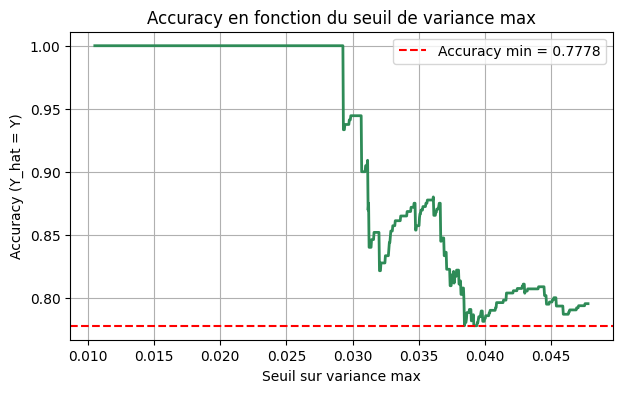

In [21]:
accuracy_threshold(Y_hat, Y, metric_values['variance_max'], metric_name="variance max", color="seagreen")

Seuil de PE_predicted

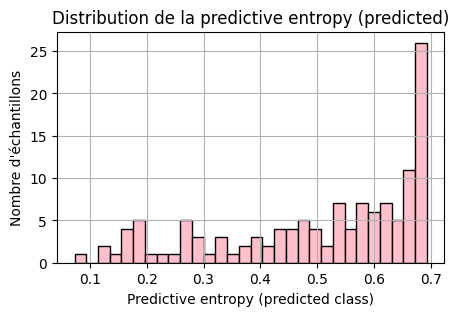

In [22]:
entropies = metric_values['predictive_entropy_predicted']
if torch.is_tensor(entropies):
    entropies = entropies.cpu().numpy()

plt.figure(figsize=(5,3))
plt.hist(entropies, bins=30, color='pink', edgecolor='black')
plt.xlabel("Predictive entropy (predicted class)")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution de la predictive entropy (predicted)")
plt.grid(True)
plt.show()

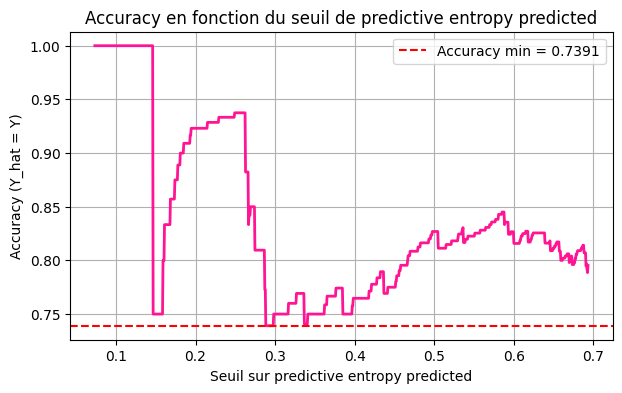

In [23]:
accuracy_threshold(Y_hat, Y, metric_values['predictive_entropy_predicted'], metric_name="predictive entropy predicted", color="deeppink")

Seuil de PE_max

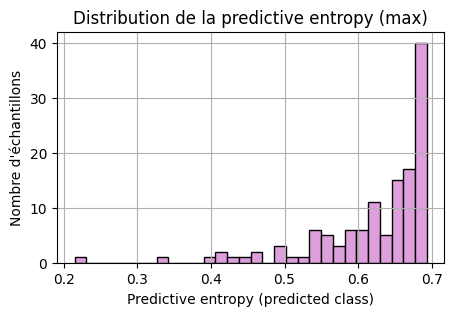

In [24]:
entropies = metric_values['predictive_entropy_max']
if torch.is_tensor(entropies):
    entropies = entropies.cpu().numpy()

plt.figure(figsize=(5,3))
plt.hist(entropies, bins=30, color='plum', edgecolor='black')
plt.xlabel("Predictive entropy (predicted class)")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution de la predictive entropy (max)")
plt.grid(True)
plt.show()

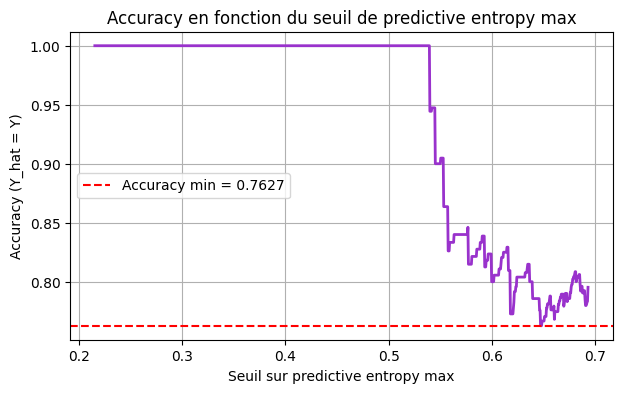

In [25]:
accuracy_threshold(Y_hat, Y, metric_values['predictive_entropy_max'], metric_name="predictive entropy max", color="darkorchid")

Pénalité

In [37]:
def compute_accuracy_penalty(accuracies):
    """
    Calcule la pénalité totale pour les montées de la courbe d'accuracy.
    La pénalité est la somme des valeurs absolues des montées (différences positives entre points consécutifs).
    """
    penalty = 0.0
    accuracies = np.array(accuracies)
    for i in range(1, len(accuracies)):
        if np.isnan(accuracies[i-1]) or np.isnan(accuracies[i]):
            continue
        diff = accuracies[i] - accuracies[i-1]
        if diff > 0:
            penalty += abs(diff)
    return penalty

# Exemple d'utilisation après avoir appelé accuracy_threshold :
# thresholds, accuracies = ... (récupérez-les dans accuracy_threshold ou modifiez accuracy_threshold pour les retourner)
# penalty = compute_accuracy_penalty(accuracies)
# print(f"Pénalité totale pour les montées de la courbe : {penalty:.4f}")

In [38]:

# Récupérer thresholds et accuracies pour variance_max
def accuracy_threshold_return(Y_hat, Y, values, metric_name="mesure", num_thresholds=1000, color='blue'):
    """
    Identique à accuracy_threshold mais retourne thresholds et accuracies.
    """
    if torch.is_tensor(Y_hat): Y_hat = Y_hat.cpu().numpy()
    if torch.is_tensor(Y): Y = Y.cpu().numpy()
    if torch.is_tensor(values): values = values.cpu().numpy()

    thresholds = np.linspace(values.min(), values.max(), num_thresholds)
    accuracies = []

    for thresh in thresholds:
        mask = values < thresh
        if mask.sum() == 0:
            accuracies.append(np.nan)
        else:
            acc = (Y_hat[mask] == Y[mask]).mean()
            accuracies.append(acc)

    accuracies = np.array(accuracies)
    min_accuracy = np.nanmin(accuracies)

    plt.figure(figsize=(7,4))
    plt.plot(thresholds, accuracies, color=color, linewidth=2)
    plt.axhline(y=min_accuracy, color='red', linestyle='--', label=f"Accuracy min = {min_accuracy:.4f}")
    plt.xlabel(f"Seuil sur {metric_name}")
    plt.ylabel("Accuracy (Y_hat = Y)")
    plt.title(f"Accuracy en fonction du seuil de {metric_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    return thresholds, accuracies


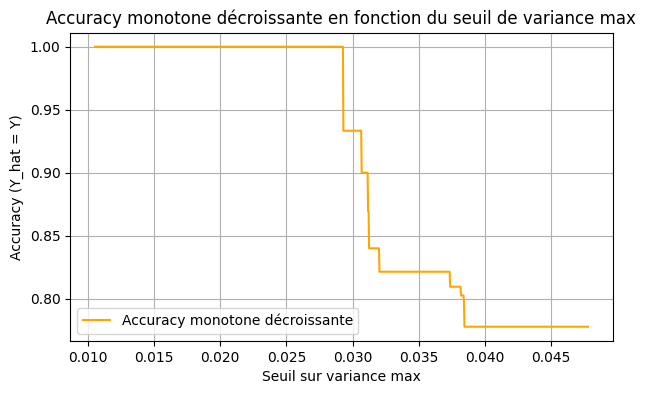

In [39]:
def make_monotonic_decreasing(arr):
    """
    Rend un tableau monotone décroissant en remplaçant chaque valeur qui monte
    par la valeur précédente (aplatit les montées).
    """
    arr = np.array(arr).copy()
    for i in range(1, len(arr)):
        if np.isnan(arr[i-1]):
            continue
        if arr[i] > arr[i-1]:
            arr[i] = arr[i-1]
    return arr

# Exemple d'utilisation :
# monotone_accuracies = make_monotonic_decreasing(accuracies)
# plt.plot(thresholds, monotone_accuracies)
# Calcul et affichage de la courbe monotone décroissante pour variance_max
monotone_accuracies = make_monotonic_decreasing(accuracies)
plt.figure(figsize=(7,4))
plt.plot(thresholds, monotone_accuracies, color="orange", label="Accuracy monotone décroissante")
plt.xlabel("Seuil sur variance max")
plt.ylabel("Accuracy (Y_hat = Y)")
plt.title("Accuracy monotone décroissante en fonction du seuil de variance max")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
def penalty_linear(accuracies):
    penalty = 0.0
    for i in range(1, len(accuracies)):
        if np.isnan(accuracies[i-1]) or np.isnan(accuracies[i]):
            continue
        diff = accuracies[i] - accuracies[i-1]
        if diff > 0:
            penalty += abs(diff)
    return penalty


In [41]:
def penalty_quadratic(accuracies):
    penalty = 0.0
    for i in range(1, len(accuracies)):
        if np.isnan(accuracies[i-1]) or np.isnan(accuracies[i]):
            continue
        diff = accuracies[i] - accuracies[i-1]
        if diff > 0:
            penalty += diff ** 2
    return penalty


In [42]:
def penalty_LOM(accuracies):
    num = 0.0
    denom = 0.0
    for i in range(1, len(accuracies)):
        if np.isnan(accuracies[i-1]) or np.isnan(accuracies[i]):
            continue
        diff = accuracies[i] - accuracies[i-1]
        if diff > 0:
            num += diff
        denom += abs(diff)
    return num / denom if denom > 0 else 0.0


In [43]:
def penalty_L1_to_monotonic(accuracies):
    monotone = make_monotonic_decreasing(accuracies)
    # Ne pas pénaliser là où l'accuracy de base est nan
    mask = ~np.isnan(accuracies)
    return np.sum(np.abs(monotone[mask] - np.array(accuracies)[mask]))


In [44]:
def penalty_count_violations(accuracies):
    count = 0
    for i in range(1, len(accuracies)):
        if np.isnan(accuracies[i-1]) or np.isnan(accuracies[i]):
            continue
        if accuracies[i] > accuracies[i-1]:
            count += 1
    return count, count / (len(accuracies)-1)


Pénalité linéaire : 0.23938482786016324
Pénalité quadratique : 0.000908347165981307
Indice LOM : 0.35023687850299373
Nombre de violations : 75 | Proportion : 0.075


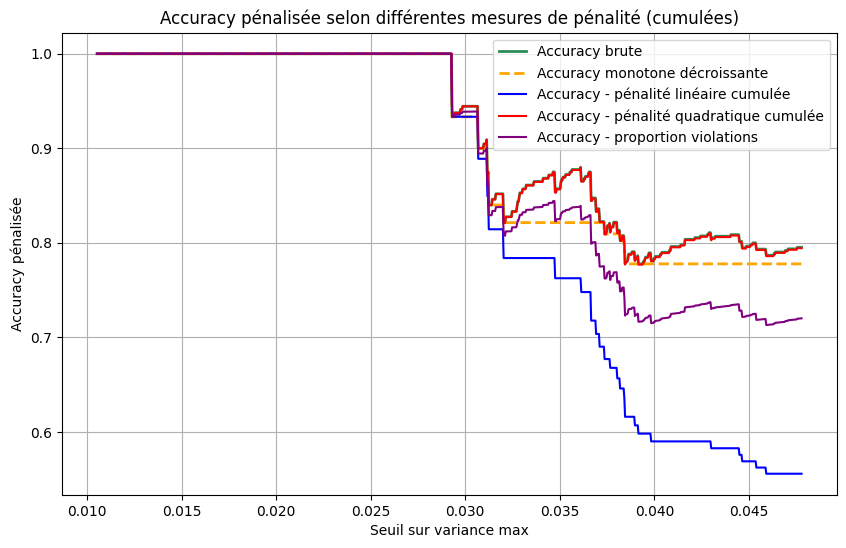

In [ ]:
thresholds, accuracies = accuracy_threshold_return(
    Y_hat, Y, metric_values['variance_max'], metric_name="variance max", color="seagreen"
)

print("Pénalité linéaire :", penalty_linear(accuracies))
print("Pénalité quadratique :", penalty_quadratic(accuracies))
print("Indice LOM :", penalty_LOM(accuracies))
violations, prop_violations = penalty_count_violations(accuracies)
print(f"Nombre de violations : {violations} | Proportion : {prop_violations:.3f}")

# Tracer plusieurs courbes d'accuracy pénalisée selon différentes pénalités

plt.figure(figsize=(10,6))
plt.plot(thresholds, accuracies, label="Accuracy brute", color="seagreen", linewidth=2)

# Courbe monotone décroissante (référence)
monotone_accuracies = make_monotonic_decreasing(accuracies)
plt.plot(thresholds, monotone_accuracies, color="orange", linestyle="--", linewidth=2, label="Accuracy monotone décroissante")

# Courbe accuracy - pénalité linéaire cumulée
penalty_lin = np.zeros_like(accuracies)
for i in range(1, len(accuracies)):
    if np.isnan(accuracies[i-1]) or np.isnan(accuracies[i]):
        penalty_lin[i] = penalty_lin[i-1]
    else:
        diff = accuracies[i] - accuracies[i-1]
        penalty_lin[i] = penalty_lin[i-1] + (diff if diff > 0 else 0)
plt.plot(thresholds, accuracies - penalty_lin, label="Accuracy - pénalité linéaire cumulée", color="blue")

# Courbe accuracy - pénalité quadratique cumulée
penalty_quad = np.zeros_like(accuracies)
for i in range(1, len(accuracies)):
    if np.isnan(accuracies[i-1]) or np.isnan(accuracies[i]):
        penalty_quad[i] = penalty_quad[i-1]
    else:
        diff = accuracies[i] - accuracies[i-1]
        penalty_quad[i] = penalty_quad[i-1] + (diff**2 if diff > 0 else 0)
plt.plot(thresholds, accuracies - penalty_quad, label="Accuracy - pénalité quadratique cumulée", color="red")

# Courbe accuracy - proportion de violations (chaque point = nb violations jusqu'ici / i)
penalty_viol = np.zeros_like(accuracies)
count = 0
for i in range(1, len(accuracies)):
    if np.isnan(accuracies[i-1]) or np.isnan(accuracies[i]):
        penalty_viol[i] = penalty_viol[i-1]
    else:
        if accuracies[i] > accuracies[i-1]:
            count += 1
        penalty_viol[i] = count / i
plt.plot(thresholds, accuracies - penalty_viol, label="Accuracy - proportion violations", color="purple")

# # Courbe accuracy - distance L1 à la version monotone (cumulée)
# penalty_l1 = np.abs(monotone_accuracies - accuracies)
# penalty_l1_cum = np.cumsum(np.nan_to_num(penalty_l1))
# plt.plot(thresholds, accuracies - penalty_l1_cum, label="Accuracy - L1 à monotone cumulée", color="green")

plt.xlabel("Seuil sur variance max")
plt.ylabel("Accuracy pénalisée")
plt.title("Accuracy pénalisée selon différentes mesures de pénalité (cumulées)")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
from sklearn.isotonic import IsotonicRegression
import numpy as np
import matplotlib.pyplot as plt

# Supposons que thresholds et accuracies sont déjà calculés par ta fonction accuracy_threshold_return
# thresholds : array des seuils (ordonnés)
# accuracies : array des accuracy correspondantes (non monotones)

mask = ~np.isnan(accuracies)
iso_reg = IsotonicRegression(increasing=False, out_of_bounds='clip')
monotone_accuracies_iso = iso_reg.fit_transform(thresholds[mask], accuracies[mask])


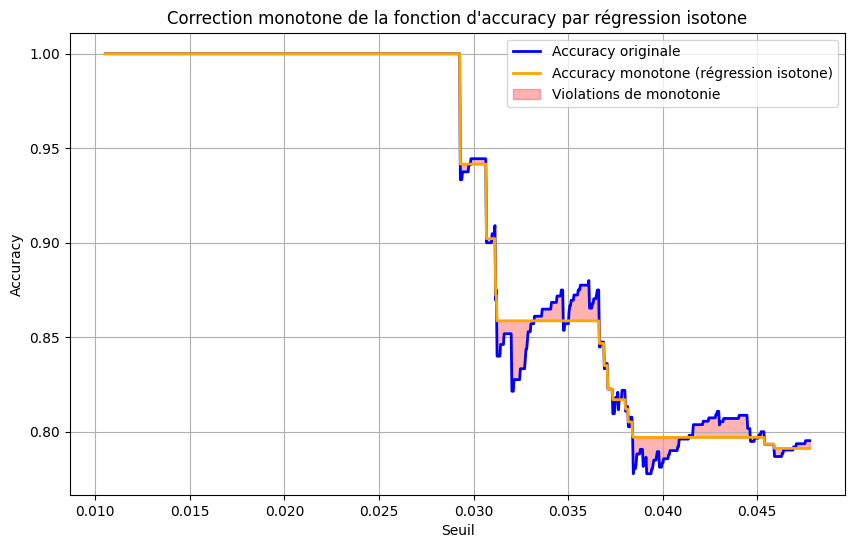

In [60]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracies, label='Accuracy originale', color='blue', linewidth=2)
plt.plot(thresholds[mask], monotone_accuracies_iso, label='Accuracy monotone (régression isotone)', color='orange', linewidth=2)
plt.fill_between(thresholds[mask], monotone_accuracies_iso, accuracies[mask],
                 color='red', alpha=0.3, label='Violations de monotonie')
plt.xlabel('Seuil')
plt.ylabel('Accuracy')
plt.title("Correction monotone de la fonction d'accuracy par régression isotone")
plt.legend()
plt.grid(True)
plt.show()

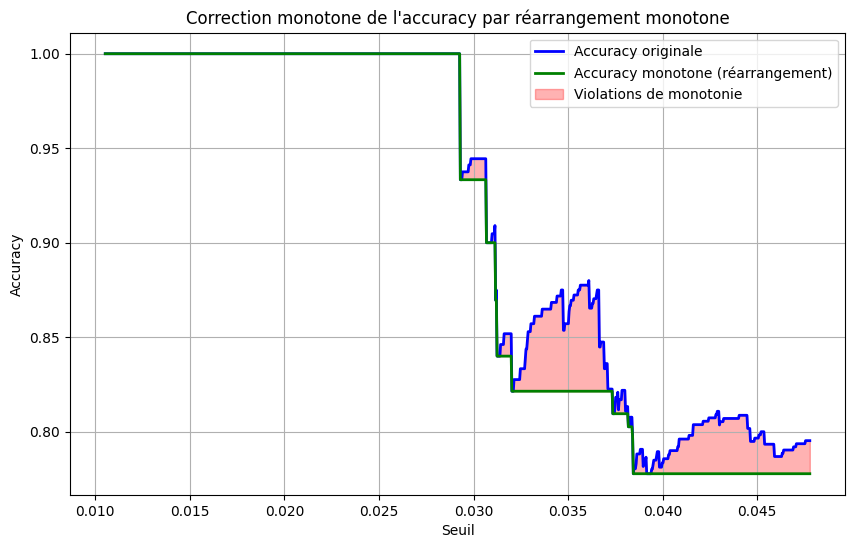

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def make_monotonic_decreasing(arr):
    arr = np.array(arr).copy()
    for i in range(1, len(arr)):
        if np.isnan(arr[i-1]):
            continue
        if arr[i] > arr[i-1]:
            arr[i] = arr[i-1]
    return arr

# Supposons que thresholds et accuracies viennent de ta fonction accuracy_threshold_return

# Calcul du réarrangement monotone (fonction décroissante)
monotone_accuracies_rearranged = make_monotonic_decreasing(accuracies)

# Tracé comparatif
plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracies, label='Accuracy originale', color='blue', linewidth=2)
plt.plot(thresholds, monotone_accuracies_rearranged, label='Accuracy monotone (réarrangement)', color='green', linewidth=2)
plt.fill_between(thresholds, monotone_accuracies_rearranged, accuracies,
                 color='red', alpha=0.3, label='Violations de monotonie')
plt.xlabel('Seuil')
plt.ylabel('Accuracy')
plt.title("Correction monotone de l'accuracy par réarrangement monotone")
plt.legend()
plt.grid(True)
plt.show()
